Dataset Overview:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

PART 1: LINEAR REGRESSION MODELING
Linear Regression R² Score: 0.0698


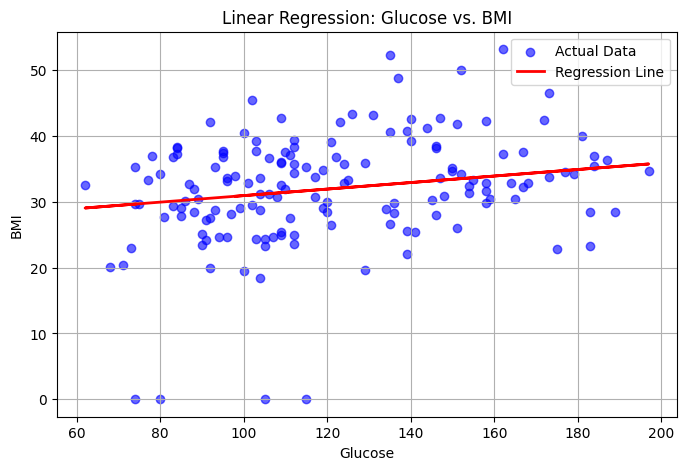


PART 2: LOGISTIC REGRESSION MODELING
Logistic Regression Accuracy: 75.32%

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82        99
           1       0.70      0.55      0.61        55

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



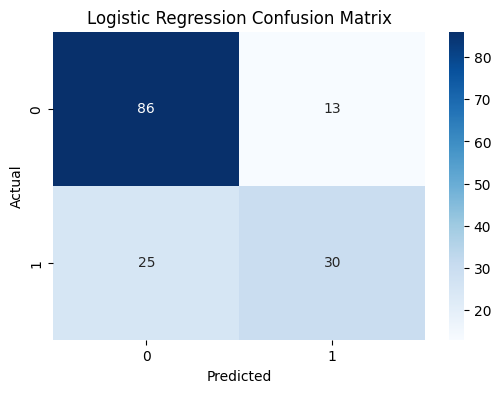

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report

# 1. Load the Dataset from Public Source
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load into DataFrame (Used for both UCI & Pima analysis)
df = pd.read_csv(url, names=columns)

print("Dataset Overview:")
print(df.head())

# ==========================================
# PART 1: LINEAR REGRESSION (Glucose vs. BMI)
# ==========================================
print("\n" + "="*50)
print("PART 1: LINEAR REGRESSION MODELING")
print("="*50)

# Define Independent (X) and Dependent (y) variables
X_lin = df[['Glucose']]
y_lin = df['BMI']

# Split Data (80% Train, 20% Test)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

# Train Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

# Predictions & Evaluation
y_pred_lin = lin_model.predict(X_test_lin)
r2 = r2_score(y_test_lin, y_pred_lin)

print(f"Linear Regression R² Score: {r2:.4f}")

# Plotting Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lin, y_test_lin, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test_lin, y_pred_lin, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Glucose vs. BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# PART 2: LOGISTIC REGRESSION (Glucose vs. Outcome)
# ==========================================
print("\n" + "="*50)
print("PART 2: LOGISTIC REGRESSION MODELING")
print("="*50)

# Define Independent (X) and Dependent (y) variables
X_log = df[['Glucose']]
y_log = df['Outcome']

# Split Data (80% Train, 20% Test)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Train Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train_log, y_train_log)

# Predictions & Evaluation
y_pred_log = log_model.predict(X_test_log)
accuracy = accuracy_score(y_test_log, y_pred_log)

print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test_log, y_pred_log))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_log, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()